In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib as mpl

import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Roboto"]
mpl.rcParams["figure.dpi"] = 100

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 12

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 12,
    "axes.titleweight": "regular",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})

In [2]:
def evolve(x0, y0, f, N=1, crit=0):
  traj = np.zeros((N+1, 8))
  traj[0] = np.array([*x0, *y0])
  x = x0
  y = y0

  for t in range(1, N+1):
    if t % 25 == 0:
        # print(f"LD at {t}: {x[0]*x[3]-x[1]*x[2] + y[0]*y[3]-y[1]*y[2]:.8f}")
        # print(f"LD at {t}: {(x[0]+y[0])*(x[3]+y[3])-(x[1]+y[1])*(x[2]+y[2]):.8f}")
        
        c=0.5
        s = 0.1
        R0 = 1-s/2
        w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
        w_bar = np.dot(x, w) + np.dot(y, w)
        Ds = (w[0]*w[3]*(x[0]+y[0])*(x[3]+y[3]) - w[1]*w[2]*(x[1]+y[1])*(x[2]+y[2])) / w_bar**2
        # print(f"Expected LD: {(1-c)*Ds:.8f}\n")
        
    if (t+1)%250 == 0:
      um1 = x.sum()
      um2 = y.sum()
      r_11 = 0.010000
      r_22 = 0.336667
      r_12 = 0.173333
      
      reff = r_11 * um1**2 + 2*r_12*um1*um2 + r_22 * um2**2
      print(f"reff at {t+1}: {reff} <? {(0.1 / 1.1)}")
        
    if t == crit:
      # amt = 0.5
      # y = amt * x.copy()
      # x = (1-amt)* x
      amt = 0.001
      y[3]+=amt
      freq_total = x.sum() + y.sum()
      x /= freq_total
      y /= freq_total
      
    #   if t % 100 == 0:
    #       print(x, y)
    x, y = f(x, y)
    traj[t] = np.array([*x, *y])

  return traj

def plot_traj(traj, N_gen):
    generations = np.arange(traj.shape[0])
    labels = [r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$", r"$y_1$", r"$y_2$", r"$y_3$", r"$y_4$"]
    colors = ['navy', 'forestgreen', 'purple', 'crimson']

    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    for i in range(4):
        plt.plot(generations, traj[:, i], label=labels[i], color=colors[i], alpha=0.7)
    for i in range(4):
        plt.plot(generations, traj[:, i+4], label=labels[i+4], color=colors[i], alpha=0.7, ls='--')

    plt.ylim(-0.05, 1.05)
    plt.xlim(0, N_gen)
    plt.ylabel('Frequency')
    plt.xlabel('Generation')
    plt.title(r'Invasion') # for $r_{12}=r_{22}=0.05$ with Invasion of $M_2$ into $M_1$
    plt.legend()
    plt.show()

def evolve_traj(f, x_init=np.zeros(4), y_init=np.zeros(4), N_gen=2000):
  traj = evolve(x_init, y_init, f, N_gen)
  plot_traj(traj, N_gen)
  return traj

reff at 250: 0.13765376723491726 <? 0.09090909090909091
reff at 500: 0.13048321513597738 <? 0.09090909090909091
reff at 750: 0.12541749404425112 <? 0.09090909090909091
reff at 1000: 0.113204267721191 <? 0.09090909090909091
reff at 1250: 0.03558179964639126 <? 0.09090909090909091
reff at 1500: 0.03558179671018611 <? 0.09090909090909091
reff at 1750: 0.03558179671018611 <? 0.09090909090909091
reff at 2000: 0.03558179671018611 <? 0.09090909090909091


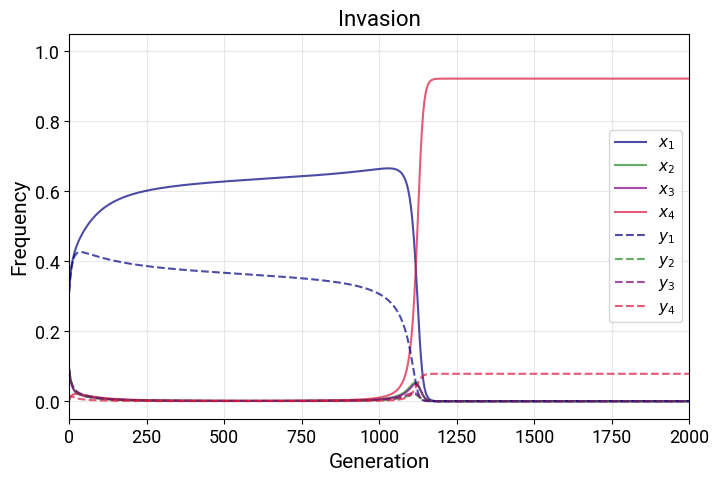

[1.19284175e-47 3.74950313e-48 3.93137835e-48 9.21688236e-01
 3.28394389e-49 8.22347505e-49 6.40472290e-49 7.83117636e-02]


In [3]:
def f(x, y):
  s = 0.1
  R0 = 1-s/2
  w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
  w_bar = np.dot(x, w) + np.dot(y, w)
  
  r_11 = 0.010000
  r_22 = 0.336667
  r_12 = 0.173333 # 0.5*(r_1 + r_2)
  r = 0.1000

  # 0: ab, 1: Ab, 2: aB, 3: AB
  # x: modifier m, y: modifier M
  x_prime = np.zeros(4)
  y_prime = np.zeros(4)
  
  cross_loss_indices = [
    [1, 2, 3, 3],  # abm with AbM, abM, ABM
    [0, 3, 2, 2],  # Abm with abM, ABM, aBM
    [3, 0, 1, 1],  # aBm with ABM, abM, AbM
    [2, 1, 0, 0],  # ABm with aBM, AbM, abM
  ]

  # x[i] * y[j]
  cross_gain_pairs = [
    [(1,2), (1,0), (2,1), (2, 0)], # ab
    [(0,3), (0,1), (3,0), (3,1)], # Ab
    [(3,0), (3,2), (0,3), (0,2)], # aB
    [(2,1), (2,3), (1,2), (1,3)] # AB
  ]

  x = x*w / w_bar
  y = y*w / w_bar
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_11 * (x[0]*x[3] - x[1]*x[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (x[i1] * (y[2] + y[3]) - x[i2] * (y[0] + y[1]))
    
    # Recombination between the B and M loci
    # reco_bm = r * (sum([x[i] * y[j] for j in range(4) if j != i]) - sum([y[i] * x[j] for j in range(4) if j != i]))
    reco_bm = r * (x[i] * (y.sum() - y[i]) - y[i] * (x.sum() - x[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*x[i]*y[il] - 2*x[il]*y[i] + x[i]*y[3-i] + x[ia]*y[3-ia] - x[3-i]*y[i] - x[3-ia]*y[ia])
    
    x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
    
    # # Old code without r
    # loss = -0.5 * r_h * [x[i] * y[cross_loss_indices[i]]].sum()
    # gain = 0.5 * r_h * sum(x[j]*y[k] for (j,k) in cross_gain_pairs[i])
    # gain_brute = cross_recombination_gain(x, y, r_h)

    # x_prime[i] = x[i] + within + loss + gain
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_22 * (y[0]*y[3] - y[1]*y[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (y[i1] * (x[2] + x[3]) - y[i2] * (x[0] + x[1]))
    
    # Recombination between the B and M loci
    reco_bm = r * (y[i] * (x.sum() - x[i]) - x[i] * (y.sum() - y[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*y[i]*x[il] - 2*y[il]*x[i] + y[i]*x[3-i] + y[ia]*x[3-ia] - y[3-i]*x[i] - y[3-ia]*x[ia])
    
    y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
    
    # # Old code without r
    # sgn = -1 if i in [0,3] else 1
    # within = sgn * r_2 * (y[0]*y[3] - y[1]*y[2])
    # loss = -0.5 * r_h * y[i] * x[cross_loss_indices[i]].sum()
    # gain = 0.5 * r_h * sum(y[j]*x[k] for (j,k) in cross_gain_pairs[i])

    # y_prime[i] = y[i] + within + loss + gain
  
  total = x_prime.sum() + y_prime.sum()
  x_prime /= total
  y_prime /= total
  return x_prime, y_prime

# Initialization
x1 = 0.6
x4 = 0.05
x2 = (1 - x1 - x4) / 2
x3 = x2

total = 0.0
y_r = np.random.dirichlet(np.ones(4)) * total


x_init = np.array([x1, x2, x3, x4])
y_init = np.array(y_r)
y_init = np.array([x1, x2, x3, x4])

x_init = np.array([0.314474,	0.090263,	0.090263,	0.005000])
y_init = np.array([0.314474,	0.090263,	0.090263,	0.005000])

# Normalization
freq_total = x_init.sum() + y_init.sum()
x_init /= freq_total
y_init /= freq_total



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 14,
    "axes.titleweight": "regular",
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})

traj = evolve_traj(f, x_init, y_init, 2000)
print(traj[-1])

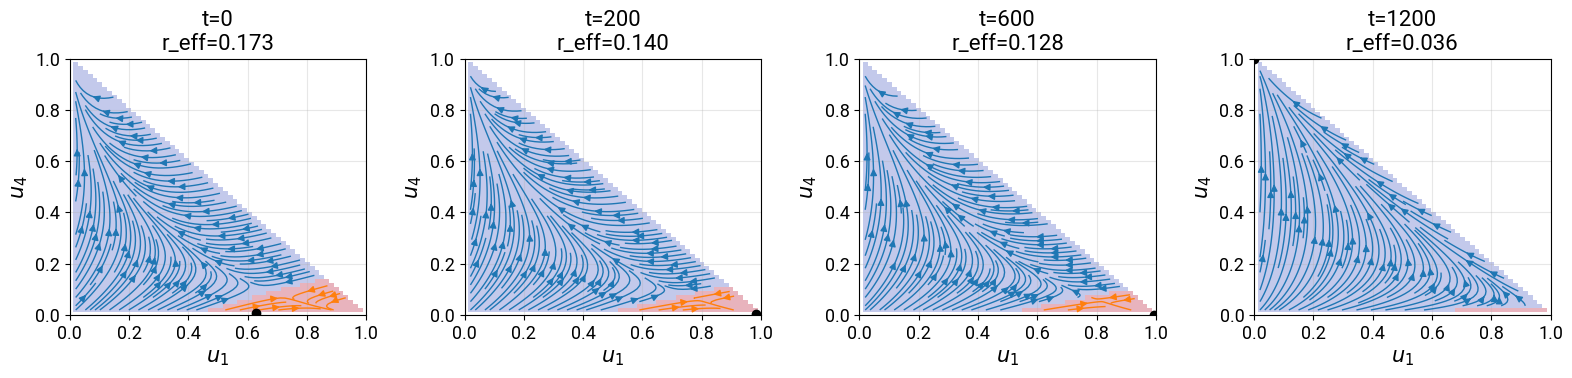

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ---------- Core dynamics ----------

def fitness_weights(s=0.1):
    R0 = 1 - s/2
    return np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])

def phase_step(x, r, w):
    w_bar = x @ w
    D = (w[0]*w[3]*x[0]*x[3] - w[1]*w[2]*x[1]*x[2]) / w_bar**2
    x_next = np.empty_like(x)
    for i in range(4):
        sgn = -1 if i in [0,3] else 1
        x_next[i] = x[i]*w[i]/w_bar + sgn * r * D
    return x_next

def full_step(x, y, params):
    w = params["w"]
    r11, r22, r12, r = params["r11"], params["r22"], params["r12"], params["r"]

    w_bar = x @ w + y @ w
    x, y = x*w/w_bar, y*w/w_bar

    def update(a, b, r_self):
        out = np.zeros(4)
        for i in range(4):
            il = (i + 2) % 4
            ia = i - 1 if i % 2 else i + 1

            sgn_wtn = 1 if i in [0,3] else -1
            wtn = sgn_wtn * r_self * (a[0]*a[3] - a[1]*a[2])

            i1, i2 = min(i, il), max(i, il)
            sgn_btwn = -1 if i in [2,3] else 1
            btwn = sgn_btwn * r12 * (a[i1]*(b[2]+b[3]) - a[i2]*(b[0]+b[1]))

            bm = r * (a[i]*(b.sum()-b[i]) - b[i]*(a.sum()-a[i]))

            dbl = r*r12*(2*a[i]*b[il] - 2*a[il]*b[i]
                         + a[i]*b[3-i] + a[ia]*b[3-ia]
                         - a[3-i]*b[i] - a[3-ia]*b[ia])

            out[i] = a[i] - wtn - btwn - bm + dbl
        return out

    x_p = update(x, y, r11)
    y_p = update(y, x, r22)

    total = x_p.sum() + y_p.sum()
    return x_p/total, y_p/total

# ---------- Simulation ----------

def simulate(x0, y0, params, T=2000):
    traj = np.zeros((T, 8))
    reffs = np.zeros(T)

    x, y = x0.copy(), y0.copy()

    for t in range(T):
        traj[t] = np.concatenate([x, y])

        um1, um2 = x.sum(), y.sum()
        reffs[t] = params["r11"]*um1**2 + 2*params["r12"]*um1*um2 + params["r22"]*um2**2

        x, y = full_step(x, y, params)

    return traj, reffs

# ---------- Phase plane ----------

def make_phase_plane(r, w, n=60, steps=80):
    grid = np.linspace(0.02, 0.98, n)
    x1g, x4g = np.meshgrid(grid, grid)
    mask = (x1g + x4g) <= 1

    dx1 = np.zeros_like(x1g)
    dx4 = np.zeros_like(x4g)
    finals = []

    for i in range(n):
        for j in range(n):
            if not mask[i,j]: continue
            x1, x4 = x1g[i,j], x4g[i,j]
            x2 = x3 = (1 - x1 - x4)/2
            x = np.array([x1,x2,x3,x4])

            # local vector field
            xp = phase_step(x, r, w)
            dx1[i,j], dx4[i,j] = xp[0]-x1, xp[3]-x4

            # endpoint for clustering
            for _ in range(steps):
                x = phase_step(x, r, w)
            finals.append([x[0], x[3]])

    kmeans = KMeans(n_clusters=2, n_init=5, random_state=0).fit(finals)

    labels = np.full_like(x1g, np.nan)
    idx = 0
    for i in range(n):
        for j in range(n):
            if not mask[i,j]: continue
            labels[i,j] = kmeans.labels_[idx]
            idx += 1

    return x1g, x4g, dx1, dx4, labels

# ---------- Visualization ----------

def plot_snapshots(traj, reffs, params, times):
    w = params["w"]
    fig, axes = plt.subplots(1, len(times), figsize=(4*len(times),4))

    for ax, t in zip(axes, times):
        r = reffs[t]

        x1g, x4g, dx1, dx4, labels = make_phase_plane(r, w)

        ax.pcolormesh(x1g, x4g, labels, cmap="coolwarm", shading="auto", alpha=0.3)

        for lab in [0,1]:
            mask = (labels == lab)
            ax.streamplot(
                x1g, x4g,
                np.ma.masked_where(~mask, dx1),
                np.ma.masked_where(~mask, dx4),
                density=2, linewidth=1
            )

        # project trajectory point (x+y)
        xt = traj[t,:4] + traj[t,4:]
        ax.plot(xt[0], xt[3], 'ko', ms=6)

        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_title(f"t={t}\nr_eff={r:.3f}")
        ax.set_xlabel("$u_1$"); ax.set_ylabel("$u_4$")

    plt.tight_layout()
    plt.show()

# ---------- Run ----------

params = dict(
    w=fitness_weights(),
    r11=0.01,
    r22=0.336667,
    r12=0.173333,
    r=0.1
)

x_init = np.array([0.314474, 0.090263, 0.090263, 0.005])
y_init = x_init.copy()
norm = x_init.sum() + y_init.sum()
x_init /= norm; y_init /= norm

traj, reffs = simulate(x_init, y_init, params, T=1500)

times = [0, 200, 600, 1200]
plot_snapshots(traj, reffs, params, times)

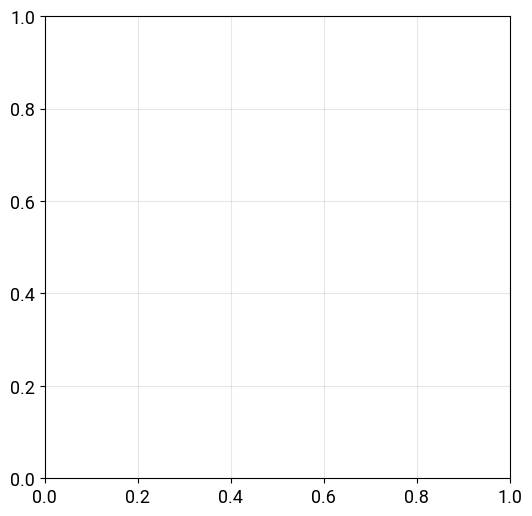

/Users/chasevanamburg/miniforge3/envs/mf/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.animation import FuncAnimation

# ---------- Core ----------

def fitness_weights(s=0.1):
    R0 = 1 - s/2
    return np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])

def phase_step(x, r, w):
    w_bar = x @ w
    D = (w[0]*w[3]*x[0]*x[3] - w[1]*w[2]*x[1]*x[2]) / w_bar**2
    out = np.empty_like(x)
    for i in range(4):
        sgn = -1 if i in [0,3] else 1
        out[i] = x[i]*w[i]/w_bar + sgn * r * D
    return out

def full_step(x, y, p):
    w = p["w"]
    r11, r22, r12, r = p["r11"], p["r22"], p["r12"], p["r"]

    w_bar = x @ w + y @ w
    x, y = x*w/w_bar, y*w/w_bar

    def upd(a, b, r_self):
        out = np.zeros(4)
        for i in range(4):
            il = (i + 2) % 4
            ia = i - 1 if i % 2 else i + 1

            sgn = 1 if i in [0,3] else -1
            wtn = sgn * r_self * (a[0]*a[3] - a[1]*a[2])

            i1, i2 = min(i, il), max(i, il)
            sgn2 = -1 if i in [2,3] else 1
            btwn = sgn2 * r12 * (a[i1]*(b[2]+b[3]) - a[i2]*(b[0]+b[1]))

            bm = r * (a[i]*(b.sum()-b[i]) - b[i]*(a.sum()-a[i]))

            dbl = r*r12*(2*a[i]*b[il] - 2*a[il]*b[i]
                        + a[i]*b[3-i] + a[ia]*b[3-ia]
                        - a[3-i]*b[i] - a[3-ia]*b[ia])

            out[i] = a[i] - wtn - btwn - bm + dbl
        return out

    x_p = upd(x, y, r11)
    y_p = upd(y, x, r22)

    tot = x_p.sum() + y_p.sum()
    return x_p/tot, y_p/tot

# ---------- Simulation ----------

def simulate(x0, y0, p, T=1000):
    traj = np.zeros((T, 8))
    reffs = np.zeros(T)

    x, y = x0.copy(), y0.copy()

    for t in range(T):
        traj[t] = np.concatenate([x, y])
        um1, um2 = x.sum(), y.sum()
        reffs[t] = p["r11"]*um1**2 + 2*p["r12"]*um1*um2 + p["r22"]*um2**2
        x, y = full_step(x, y, p)

    return traj, reffs

# ---------- Phase plane cache ----------

def compute_phase_plane(r, w, n=50, steps=60):
    grid = np.linspace(0.02, 0.98, n)
    x1g, x4g = np.meshgrid(grid, grid)
    mask = (x1g + x4g) <= 1

    dx1 = np.zeros_like(x1g)
    dx4 = np.zeros_like(x4g)
    finals = []

    for i in range(n):
        for j in range(n):
            if not mask[i,j]: continue
            x1, x4 = x1g[i,j], x4g[i,j]
            x2 = x3 = (1-x1-x4)/2
            x = np.array([x1,x2,x3,x4])

            xp = phase_step(x, r, w)
            dx1[i,j], dx4[i,j] = xp[0]-x1, xp[3]-x4

            for _ in range(steps):
                x = phase_step(x, r, w)
            finals.append([x[0], x[3]])

    kmeans = KMeans(n_clusters=2, n_init=5, random_state=0).fit(finals)

    labels = np.full_like(x1g, np.nan)
    idx = 0
    for i in range(n):
        for j in range(n):
            if not mask[i,j]: continue
            labels[i,j] = kmeans.labels_[idx]
            idx += 1

    return x1g, x4g, dx1, dx4, labels

# cache to avoid recomputation
phase_cache = {}
def get_phase(r, w, tol=0.01):
    key = round(r / tol) * tol
    if key not in phase_cache:
        phase_cache[key] = compute_phase_plane(key, w)
    return phase_cache[key]

# ---------- Animation ----------

def animate(traj, reffs, p, stride=10):
    w = p["w"]

    fig, ax = plt.subplots(figsize=(6,6))

    def update(frame):
        ax.clear()

        t = frame * stride
        if t >= len(reffs): t = len(reffs)-1

        r = reffs[t]
        x1g, x4g, dx1, dx4, labels = get_phase(r, w)

        ax.pcolormesh(x1g, x4g, labels, cmap="coolwarm", shading="auto", alpha=0.3)

        for lab in [0,1]:
            mask = (labels == lab)
            ax.streamplot(
                x1g, x4g,
                np.ma.masked_where(~mask, dx1),
                np.ma.masked_where(~mask, dx4),
                density=2, linewidth=1
            )

        xt = traj[t,:4] + traj[t,4:]
        ax.plot(xt[0], xt[3], 'ko', ms=7)

        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_title(f"t={t}   r_eff={r:.3f}")
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_4$")

    frames = len(reffs)//stride
    anim = FuncAnimation(fig, update, frames=frames, interval=80)

    plt.show()
    return anim

# ---------- Run ----------

params = dict(
    w=fitness_weights(),
    r11=0.01,
    r22=0.336667,
    r12=0.173333,
    r=0.1
)

x_init = np.array([0.314474, 0.090263, 0.090263, 0.005])
y_init = x_init.copy()
norm = x_init.sum() + y_init.sum()
x_init /= norm; y_init /= norm

traj, reffs = simulate(x_init, y_init, params, T=1200)

anim = animate(traj, reffs, params, stride=8)
anim.save("moving_separatrix.mp4", dpi=200, fps=15)